**L10 — Ćwiczenia laboratoryjne**

Temat: Seaborn + GridSpec — dashboard analityczny restauracji

Dane startowe

In [2]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
# Globalny motyw — raz, na początku notebooka
sns.set_theme(style='whitegrid', palette='muted')
# Dataset tips — restauracja, 244 rachunki (znany z W09)
tips = sns.load_dataset('tips')
print(f"Tips dataset: {tips.shape[0]} wierszy × {tips.shape[1]} kolumn")
print(f"Kolumny: {list(tips.columns)}")
tips.head(3)

Tips dataset: 244 wierszy × 7 kolumn
Kolumny: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


**Ćwiczenie 1: Statystyczne wykresy seaborn**

Cel: Stworzyć cztery statystyczne wykresy seaborn (barplot, boxplot, heatmap, scatterplot) z parametrem
hue i zapisać każdy jako PNG.

Kontekst biznesowy: Jesteś analitykiem restauracji „Pod Widelcem". Właściciel chce zobaczyć podstawowe
statystyki — średnie rachunki, rozkłady napiwków, korelacje między zmiennymi.

Zadanie 1.1 — Barplot z hue

Średni rachunek per dzień tygodnia, z podziałem wg płci.

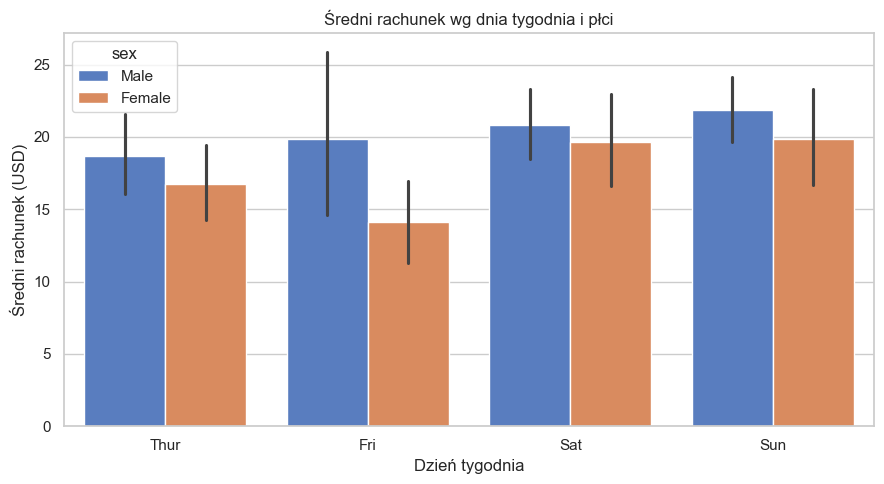

Zapisano: barplot_dzien_plec.png


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
data=tips,
x='day',
y='total_bill',
hue='sex',
ax=ax,
palette='muted',
errorbar=('ci', 95),       
# 95% CI = przedział ufności średniej
)
ax.set_title('Średni rachunek wg dnia tygodnia i płci')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Średni rachunek (USD)')
plt.tight_layout()
plt.savefig('barplot_dzien_plec.png', dpi=150, bbox_inches='tight', 
facecolor='white')
plt.show()
plt.close()
print("Zapisano: barplot_dzien_plec.png")

Pytanie kontrolne: w którym dniu szerokość wąsów (CI) jest największa? Sprawdź tips.groupby('day',
observed=True).size() — który dzień ma najmniej obserwacji, i jak wpływa to na precyzję oszacowania
średniej?

In [4]:
tips.groupby('day', observed=True).size()

day
Thur    62
Fri     19
Sat     87
Sun     76
dtype: int64

Piątek ma najmniej obserwacji ze wszystkich dni co zwiększa niepewność estymacji średniej.

Zadanie 1.2 — Boxplot

Rozkład napiwków per dzień, z podziałem na Lunch/Dinner.

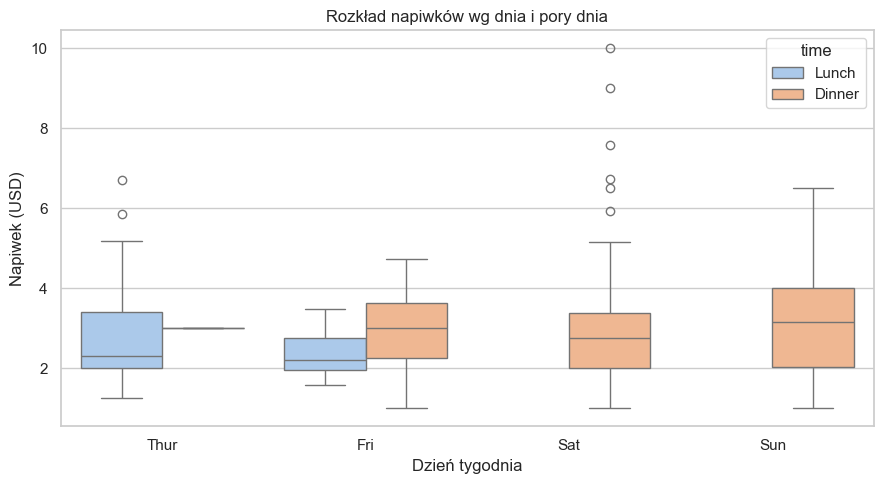

Zapisano: boxplot_napiwki.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
data=tips,
x='day',                    
y='tip',                    
hue='time',                  
ax=ax,
palette='pastel',
# kolumna kategoryczna na oś X (Thur/Fri/Sat/Sun)
# kolumna numeryczna na oś Y (napiwek)
# podział kolorystyczny (Lunch/Dinner)
)
ax.set_title('Rozkład napiwków wg dnia i pory dnia')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Napiwek (USD)')
plt.tight_layout()
plt.savefig('boxplot_napiwki.png', dpi=150, bbox_inches='tight', 
facecolor='white')
plt.show()
plt.close()
print("Zapisano: boxplot_napiwki.png")

Zadanie 1.3 — Heatmap korelacji

Macierz korelacji wszystkich zmiennych numerycznych z tips.

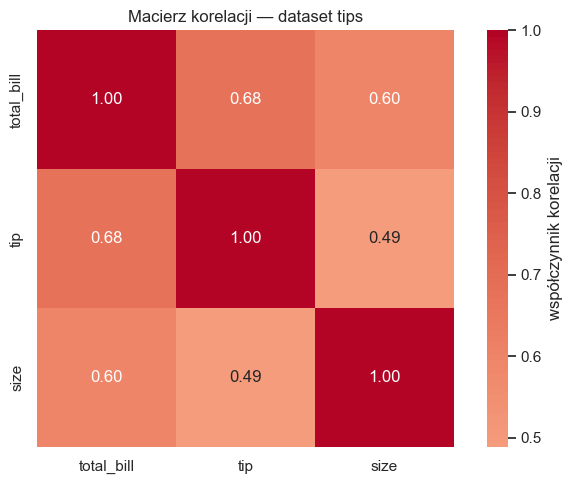

Zapisano: heatmap_korelacja.png


In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
# Korelacja tylko zmiennych numerycznych
corr = tips.select_dtypes('number').corr()
sns.heatmap(
corr,
annot=True,                
fmt='.2f',                
cmap='coolwarm',                 
center=0,               
# True — pokaż liczby w komórkach
# 2 miejsca po przecinku
ax=ax,
square=True,
cbar_kws={'label': 'współczynnik korelacji'},
)
ax.set_title('Macierz korelacji — dataset tips')
# 'coolwarm' — paleta dywergencyjna (czerwony=+, 
# 0 — środek skali (biały = 0 korelacja)
plt.tight_layout()
plt.savefig('heatmap_korelacja.png', dpi=150, bbox_inches='tight', 
facecolor='white')
plt.show()
plt.close()
print("Zapisano: heatmap_korelacja.png")

Zadanie 1.4 — Scatter z hue + style

Stwórz sns.scatterplot zależności rachunek↔napiwek, w którym:
kolor punktu zależy od 'smoker' (Yes/No)
kształt markera zależy od 'time' (Lunch/Dinner)
punkty są lekko przezroczyste (alpha)
tytuł, etykiety osi z jednostkami (USD)
Zapisz jako scatter_rachunek_napiwek.png.
Wskazówka: w seaborn hue= koloruje, style= kontroluje kształt markera. Oba przyjmują nazwę
kolumny.

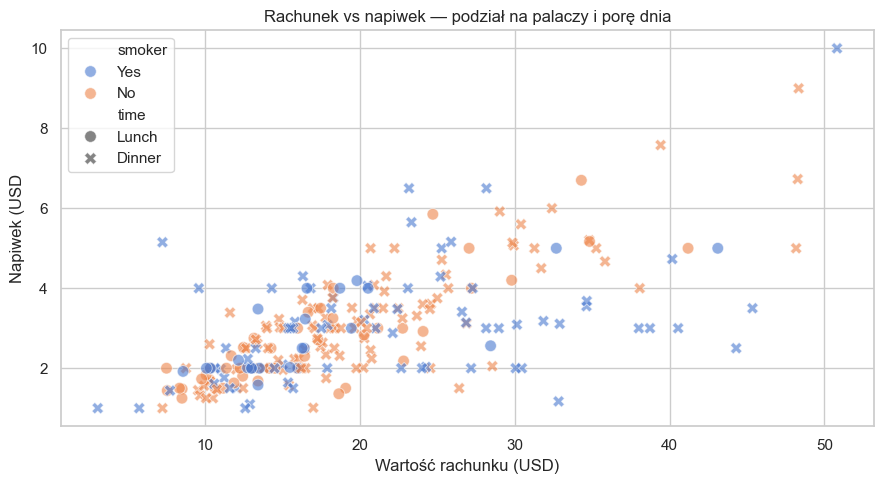

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
# Twój kod
sns.scatterplot(
data=tips,
x='total_bill',
y='tip',
hue='smoker',        
style='time',    
alpha=0.6,           
s=70,               
ax=ax)

ax.set_title('Rachunek vs napiwek — podział na palaczy i porę dnia')
ax.set_xlabel('Wartość rachunku (USD)')
ax.set_ylabel('Napiwek (USD')
plt.tight_layout()
plt.savefig('scatter_rachunek_napiwek.png', dpi=150, bbox_inches='tight', 
facecolor='white')
plt.show()
plt.close()

Zadanie dodatkowe

Stwórz sns.violinplot z split=True porównujący rozkład total_bill Lunch vs Dinner z podziałem wg
płci. Wymóg API: split=True wymaga dokładnie 2 kategorii w hue (np. sex: Male/Female).

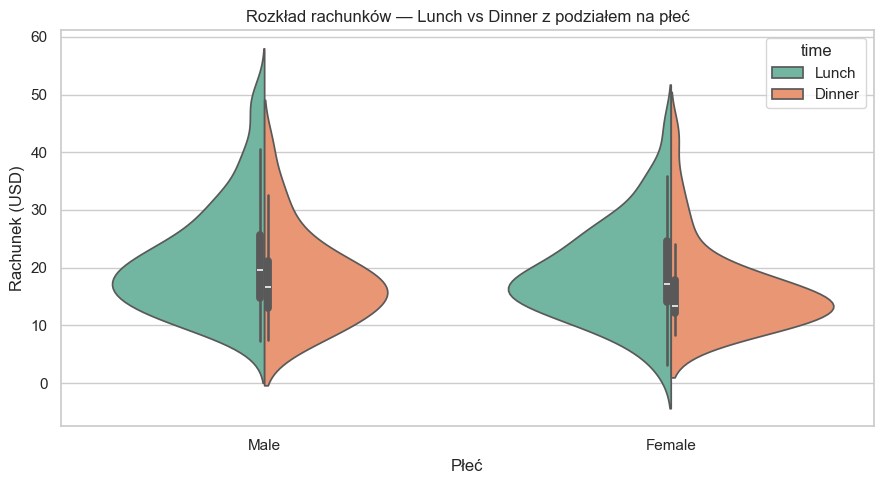

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.violinplot(
data=tips,
x='sex',          
y='total_bill',     
hue='time',
split=True,  
palette='Set2',
ax=ax)

ax.set_title('Rozkład rachunków — Lunch vs Dinner z podziałem na płeć')
ax.set_xlabel('Płeć')
ax.set_ylabel('Rachunek (USD)')

plt.tight_layout()
plt.savefig('violin_totalbill_split.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

**Ćwiczenie 2: Subplots, GridSpec, shared axes**

Cel: Opanować dwa style układu wielu paneli — regularną siatkę (subplots) i nieregularną (GridSpec).

Zadanie 2.1 — Regularna siatka 2×2

Cztery wykresy z datasetu tips na jednej figurze

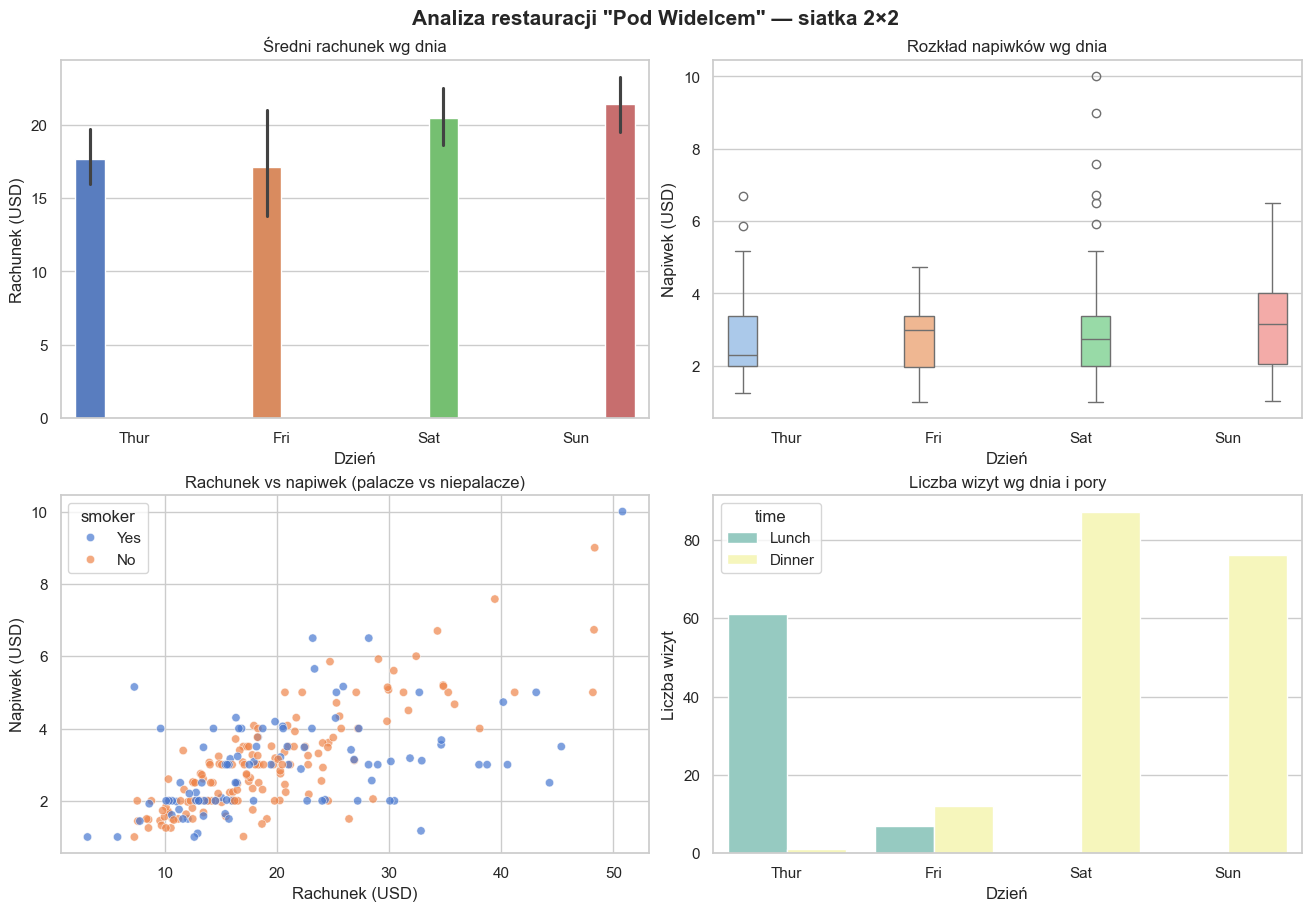

Zapisano: siatka_2x2.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
# Panel [0, 0] — barplot (gotowy wzór)
sns.barplot(data=tips, x='day', y='total_bill', hue='day', legend=False,
ax=axes[0, 0], palette='muted', errorbar=('ci', 95))
axes[0, 0].set_title('Średni rachunek wg dnia')
axes[0, 0].set_xlabel('Dzień')
axes[0, 0].set_ylabel('Rachunek (USD)')
# Panel [0, 1] — boxplot (uzupełnij)
sns.boxplot(
data=tips,
x='day',                    
# 'day'
y='tip',                    
hue='day', legend=False,
ax=axes[0, 1],
palette='pastel',
# 'tip'
)
axes[0, 1].set_title('Rozkład napiwków wg dnia')
axes[0, 1].set_xlabel('Dzień')
axes[0, 1].set_ylabel('Napiwek (USD)')
# Panel [1, 0] — scatter (uzupełnij)
sns.scatterplot(
data=tips,
x='total_bill',                    
# 'total_bill'
y='tip',                    
hue='smoker',
alpha=0.7,
ax=axes[1, 0],
# 'tip'
)
axes[1, 0].set_title('Rachunek vs napiwek (palacze vs niepalacze)')
axes[1, 0].set_xlabel('Rachunek (USD)')
axes[1, 0].set_ylabel('Napiwek (USD)')
# Panel [1, 1] — countplot (uzupełnij)
sns.countplot(
data=tips,
x='day',                    
hue='time',
ax=axes[1, 1],
palette='Set3',
# 'day'
)
axes[1, 1].set_title('Liczba wizyt wg dnia i pory')
axes[1, 1].set_xlabel('Dzień')
axes[1, 1].set_ylabel('Liczba wizyt')
fig.suptitle('Analiza restauracji "Pod Widelcem" — siatka 2×2',
fontsize=15, fontweight='bold')
plt.savefig('siatka_2x2.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: siatka_2x2.png")

Zadanie 2.2 — GridSpec — nieregularny dashboard

Stwórz Figure z GridSpec(2, 2) w której górny rząd to jeden panel (pełna szerokość), a dolny rząd ma 2
panele.

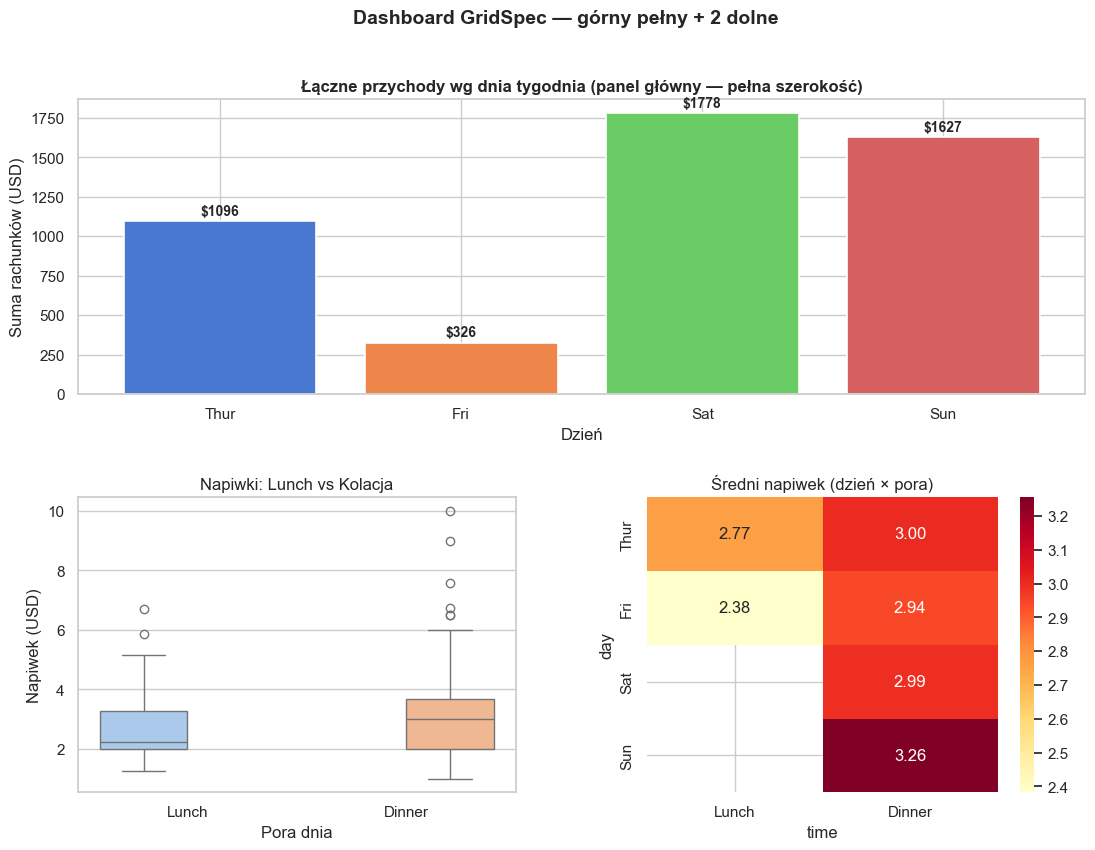

Zapisano: gridspec_dashboard.png


In [10]:
fig = plt.figure(figsize=(13, 9))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)
# Górny — pełna szerokość: barplot suma rachunków per dzień
ax_top = fig.add_subplot(gs[0, :])
tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
ax_top.bar(
    tips_sum['day'].astype(str),
    tips_sum['total_bill'],
    color=sns.color_palette('muted')[:4],
    edgecolor='white', linewidth=1.2,
)
# Dodaj wartości nad słupkami
for i, val in enumerate(tips_sum['total_bill']):
    ax_top.text(i, val + 20, f'${val:.0f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold')
ax_top.set_title('Łączne przychody wg dnia tygodnia (panel główny — pełna szerokość)',
fontsize=12, fontweight='bold')
ax_top.set_xlabel('Dzień')
ax_top.set_ylabel('Suma rachunków (USD)')
# Dolny lewy — boxplot Lunch vs Dinner (uzupełnij)
ax_bl = fig.add_subplot(gs[1, 0])
sns.boxplot(
data=tips,
x='time',                    
# 'time'
y='tip',                    
hue='time', legend=False,
ax=ax_bl,
palette='pastel',
# 'tip'
)
ax_bl.set_title('Napiwki: Lunch vs Kolacja')
ax_bl.set_xlabel('Pora dnia')
ax_bl.set_ylabel('Napiwek (USD)')
# Dolny prawy — heatmap pivot (samodzielnie)
# Cel: stwórz pivot_table — wiersze=day, kolumny=time, wartości=mean(tip)
# Zwizualizuj jako heatmap z annot=True, fmt='.2f', cmap='YlOrRd'
ax_br = fig.add_subplot(gs[1, 1])
# Twój kod:
pivot = tips.pivot_table(index='day',
columns='time',
values='tip',
aggfunc='mean')
sns.heatmap(pivot,
annot=True,
fmt='.2f',
cmap='YlOrRd',
ax=ax_br)
ax_br.set_title('Średni napiwek (dzień × pora)')
fig.suptitle('Dashboard GridSpec — górny pełny + 2 dolne',
fontsize=14, fontweight='bold')
plt.savefig('gridspec_dashboard.png', dpi=150, bbox_inches='tight', 
facecolor='white')
plt.show()
plt.close()
print("Zapisano: gridspec_dashboard.png")

Zadanie 2.3 — Shared axes

Stwórz plt.subplots(2, 2, sharex='col', sharey='row') z 4 wykresami:

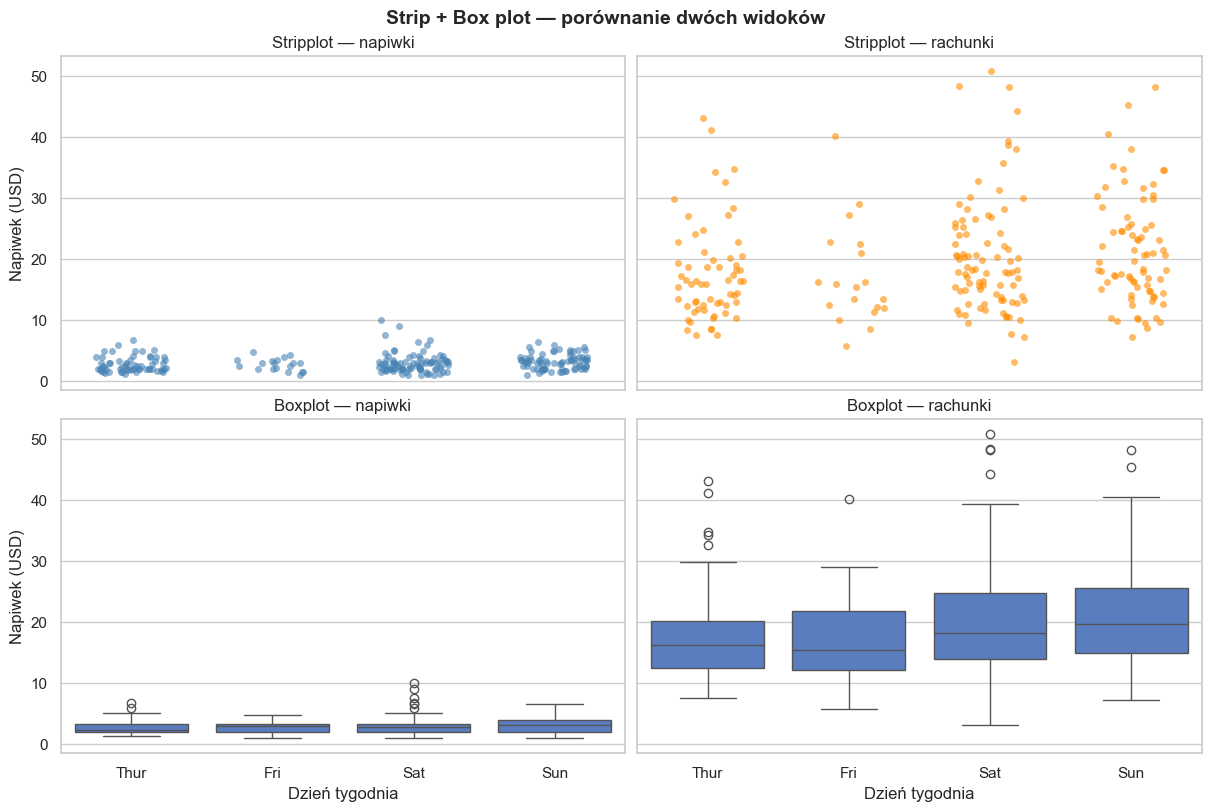

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8),
sharex='col', sharey='row',
constrained_layout=True)
# Twój kod — 4 wykresy
# axes[0, 0] stripplot napiwki
sns.stripplot(
data=tips,
x='day',
y='tip',
ax=axes[0, 0],
jitter=0.25,
alpha=0.6,
color='steelblue')
axes[0, 0].set_title('Stripplot — napiwki')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Napiwek (USD)')

# axes[1, 0] boxplot napiwki
sns.boxplot(
data=tips,
x='day',
y='tip',
ax=axes[1, 0],)
axes[1, 0].set_title('Boxplot — napiwki')
axes[1, 0].set_xlabel('Dzień tygodnia')
axes[1, 0].set_ylabel('Napiwek (USD)')

# axes[0, 1] stripplot rachunki
sns.stripplot(
data=tips,
x='day',
y='total_bill',
ax=axes[0, 1],
jitter=0.25,
alpha=0.6,
color='darkorange')
axes[0, 1].set_title('Stripplot — rachunki')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Rachunek (USD)')

# axes[1, 1] boxplot rachunki
sns.boxplot(
data=tips,
x='day',
y='total_bill',
ax=axes[1, 1],)
axes[1, 1].set_title('Boxplot — rachunki')
axes[1, 1].set_xlabel('Dzień tygodnia')
axes[1, 1].set_ylabel('Rachunek (USD)')

fig.suptitle('Strip + Box plot — porównanie dwóch widoków',
fontsize=14, fontweight='bold')
plt.savefig('shared_axes.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

**Ćwiczenie 3: Pełny dashboard analityczny**

Cel: Zaprojektować i zbudować kompletny dashboard 6-panelowy odpowiadający na pytania właściciela
restauracji.

Scenariusz biznesowy: Właściciel restauracji „Pod Widelcem" formułuje pytania analityczne:
„Jak idzie biznes? Kiedy zarabiamy najwięcej? Kto zostawia największe napiwki? Czy istnieją zależności
między zmiennymi?"

Zadanie 3.1 — Projekt dashboardu 

1. Pytanie główne (KPI): w którym dniu restauracja zarabia najwięcej? → 1 panel duży (górny, pełna
szerokość lub 2/3)
2. 3-4 panele pomocnicze: rozkład napiwków, korelacja zmiennych, scatter rachunek↔napiwek, proporcja
dni (pie/countplot)
3. 1 panel sumaryczny (dolny, pełna szerokość): rozkład rachunków per dzień (violinplot)

Zadanie 3.2 — Implementacja dashboardu

C:\Users\Katiaa\AppData\Local\Temp\ipykernel_5360\3193250839.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Katiaa\AppData\Local\Temp\ipykernel_5360\3193250839.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


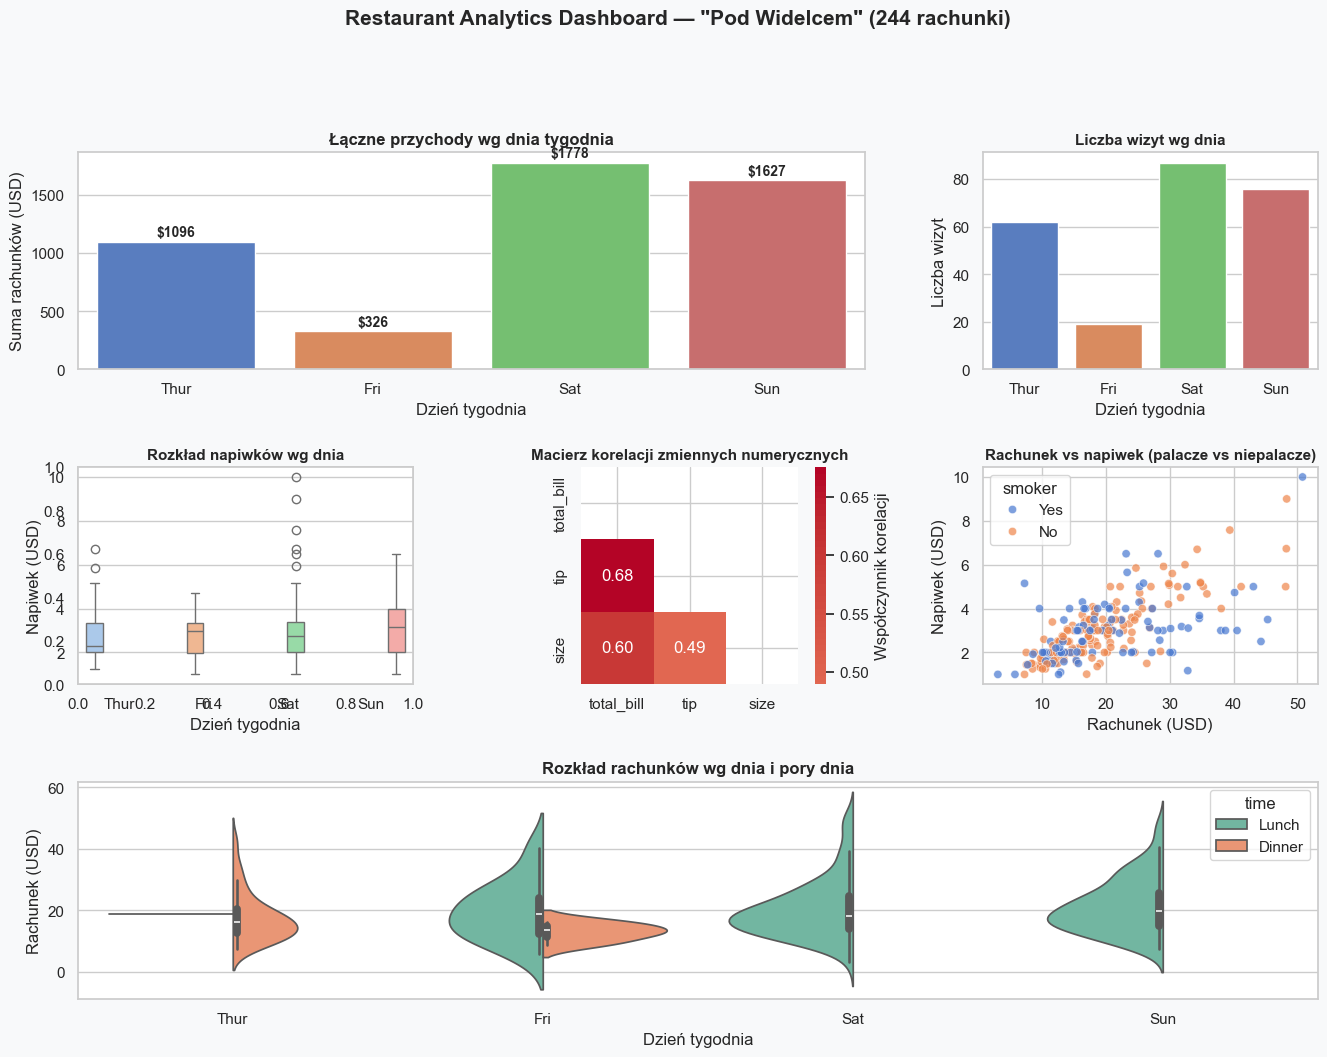

Zapisano: dashboard_pod_widelcem.png


In [13]:
# Restaurant Analytics Dashboard "Pod Widelcem"
fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor('#f8f9fa')   
# tło figury — jasnoszare
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# === PANEL 1 (KPI główny): łączne przychody per dzień (gs[0, :2]) ===
ax1 = fig.add_subplot(gs[0, :2])
# Twój kod — barplot z etykietami wartości nad słupkami
tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
sns.barplot(
data=tips_sum,
x='day',
y='total_bill',
palette='muted',
ax=ax1)
for i, row in tips_sum.iterrows():
    ax1.text(
        i,
        row['total_bill'] + 20,
        f'${row["total_bill"]:.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold')

ax1.set_title('Łączne przychody wg dnia tygodnia', fontsize=12, fontweight='bold')
ax1.set_xlabel('Dzień tygodnia')
ax1.set_ylabel('Suma rachunków (USD)')

# === PANEL 2: udział wizyt per dzień (gs[0, 2]) ===
ax2 = fig.add_subplot(gs[0, 2])
# Twój kod — pie chart lub countplot
sns.countplot(
data=tips,
x='day',
palette='muted',
ax=ax2)

ax2.set_title('Liczba wizyt wg dnia', fontsize=11, fontweight='bold')
ax2.set_xlabel('Dzień tygodnia')
ax2.set_ylabel('Liczba wizyt')

# === PANEL 3: rozkład napiwków (gs[1, 0]) ===
ax3 = fig.add_subplot(gs[1, 0])
# Twój kod — boxplot napiwki per dzień
ax3 = fig.add_subplot(gs[1, 0])
sns.boxplot(
data=tips,
x='day',
y='tip',
hue='day',
palette='pastel',
legend=False,
ax=ax3)

ax3.set_title('Rozkład napiwków wg dnia', fontsize=11, fontweight='bold')
ax3.set_xlabel('Dzień tygodnia')
ax3.set_ylabel('Napiwek (USD)')

# === PANEL 4: heatmap korelacji (gs[1, 1]) ===
ax4 = fig.add_subplot(gs[1, 1])
# Twój kod — sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
corr = tips.select_dtypes('number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    cbar_kws={'label': 'Współczynnik korelacji'},
    ax=ax4)

ax4.set_title('Macierz korelacji zmiennych numerycznych', fontsize=11, fontweight='bold')

# === PANEL 5: scatter (gs[1, 2]) ===
ax5 = fig.add_subplot(gs[1, 2])
# Twój kod — sns.scatterplot rachunek vs napiwek z hue='smoker'
sns.scatterplot(
data=tips,
x='total_bill',
y='tip',
hue='smoker',
palette='muted',
alpha=0.7,
ax=ax5)

ax5.set_title('Rachunek vs napiwek (palacze vs niepalacze)', fontsize=11, fontweight='bold')
ax5.set_xlabel('Rachunek (USD)')
ax5.set_ylabel('Napiwek (USD)')

# === PANEL 6 (sumaryczny): rozkład rachunków (gs[2, :]) ===
ax6 = fig.add_subplot(gs[2, :])
# Twój kod — sns.violinplot rachunki per dzień z hue='time', split=True
sns.violinplot(
data=tips,
x='day',
y='total_bill',
hue='time',
split=True,
palette='Set2',
ax=ax6)

ax6.set_title('Rozkład rachunków wg dnia i pory dnia', fontsize=12, fontweight='bold')
ax6.set_xlabel('Dzień tygodnia')
ax6.set_ylabel('Rachunek (USD)')

fig.suptitle('Restaurant Analytics Dashboard — "Pod Widelcem" (244 rachunki)',
fontsize=15, fontweight='bold', y=1.01)
plt.savefig('dashboard_pod_widelcem.png',
dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: dashboard_pod_widelcem.png")

Zadanie 3.3 — Wnioski biznesowe

1. Który dzień jest najbardziej dochodowy dla restauracji?

Sobota generuje najwyższe łączne przychody. Zarówno suma rachunków, jak i liczba wizyt są tam najwyższe.
Za nią plasuje się niedziela.
To oznacza, że weekend to kluczowy czas zarobkowy restauracji.

2. Czy istnieje korelacja między rachunkiem a napiwkiem? (jeśli tak — jak silna?)

Tak, korelacja jest wyraźnie dodatnia. Jest to silna, stabilna zależność: im wyższy rachunek, tym wyższy napiwek.
Scatterplot potwierdza to wizualnie — punkty układają się w rosnący trend.

3. Czy palacze i niepalacze zostawiają różne napiwki?

Tak, ale różnica nie jest ogromna. Palacze mają tendencję do nieco wyższych napiwków przy dużych rachunkach. Niepalacze są bardziej „stabilni”, mniejszy rozrzut, mniej ekstremalnych wartości.

4. Jakie ZALECENIE dasz właścicielowi na podstawie dashboardu?

- Wzmocnić obsadę i promocje w weekendy.
To dni o najwyższym ruchu i najwyższych przychodach.
Więcej kelnerów = szybsza obsługa = wyższe napiwki.

- Skupić się na klientach z dużymi rachunkami
Ponieważ korelacja rachunek ↔ napiwek jest wysoka, proponować dania premium, oferować dodatki i desery

- Zwrócić uwagę na segment palaczy
To grupa, która: częściej zostawia wyższe napiwki, generuje większe rachunki

- Utrzymać jakość obsługi wieczorem
Wieczory generują: wyższe rachunki, wyższe napiwki, większy ruch. To kluczowy moment dnia.

**Ćwiczenie 4: Style, eksport, adnotacja**

Zadanie 4.1 — Porównanie stylów seaborn

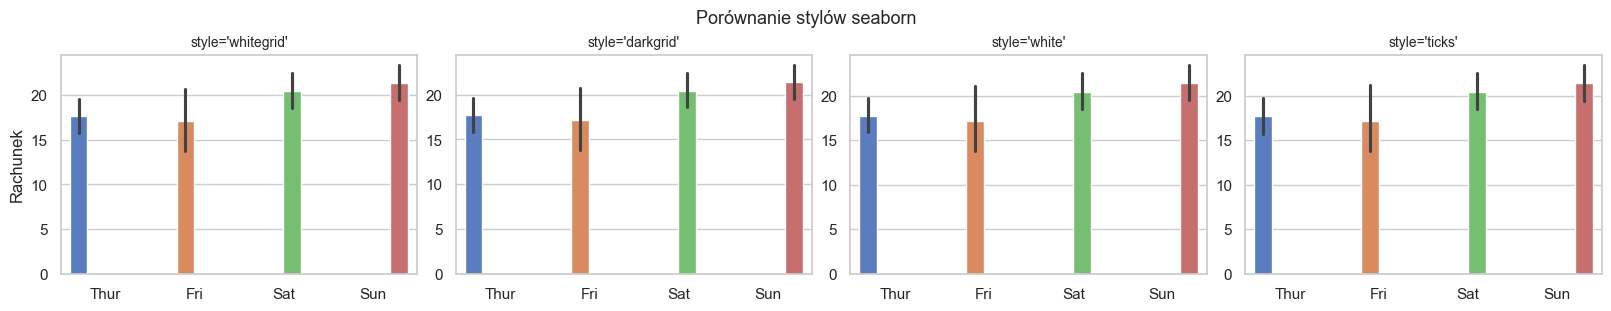

In [15]:
styles = ['whitegrid', 'darkgrid', 'white', 'ticks']
fig, axes = plt.subplots(1, 4, figsize=(16, 3), constrained_layout=True)
for ax, style in zip(axes, styles):
    with sns.axes_style(style):     
# context manager — tymczasowo zmień styl
        sns.barplot(data=tips, x='day', y='total_bill', hue='day', legend=False,
        ax=ax, palette='muted')
        ax.set_title(f"style='{style}'", fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('Rachunek' if ax is axes[0] else '')
fig.suptitle('Porównanie stylów seaborn', fontsize=13)
plt.savefig('porownanie_stylow.png', dpi=150, bbox_inches='tight', 
facecolor='white')
plt.show()
plt.close()

Pytanie kontrolne: który styl jest odpowiedni do prezentacji zarządczej (slajdy), a który do publikacji
naukowej (papier biały)?

Do prezentacji zarządczej najlepszy jest styl darkgrid, bo zapewnia wysoki kontrast i dobrą czytelność na ekranach. Do publikacji naukowej odpowiedni jest styl white lub whitegrid, ponieważ są minimalistyczne i najlepiej wyglądają w druku na białym papierze.

Zadanie 4.2 — Adnotacja na wykresie

Dodaj strzałkę wskazującą na dzień z najwyższymi przychodami 

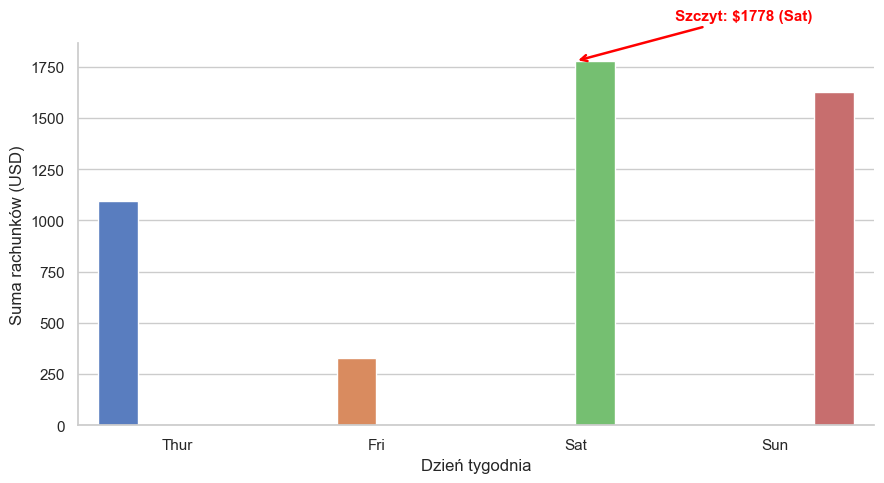

Zapisano: szczyt_przychodow.png


In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
sns.barplot(data=tips_sum, x='day', y='total_bill', hue='day', legend=False,
ax=ax, palette='muted')
# Znajdź szczyt
max_idx = tips_sum['total_bill'].idxmax()
max_day = tips_sum.loc[max_idx, 'day']
max_val = tips_sum.loc[max_idx, 'total_bill']
# Adnotacja ze strzałką
ax.annotate(
f'Szczyt: ${max_val:.0f} ({max_day})',
xy=(max_idx, max_val),                
xytext=(max_idx + 0.5, max_val + 200),            

# punkt na który wskazuje strzałka — (max_idx, 
# gdzie tekst — (max_idx + 0.5, max_val + 200)
arrowprops=dict(arrowstyle='->', color='red', lw=1.8),
fontsize=11, 
color='red', 
fontweight='bold',)
# Tytuł celowo pominięty — adnotacja 'Szczyt: $...' sama w sobie informuje o czym wykres
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Suma rachunków (USD)')
sns.despine()                     
# usuwa górną i prawą krawędź osi 
plt.tight_layout()
plt.savefig('szczyt_przychodow.png', dpi=150, bbox_inches='tight', 
facecolor='white')
plt.show()
plt.close()
print("Zapisano: szczyt_przychodow.png")